<a href="https://colab.research.google.com/github/ayushRishabhsingh/AGRONET/blob/main/Dog_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New section

# 🐶End-to-end Multi-class Dog breed classifier
This notebook builds an end-to-end dog breed classifier using TensorFlow 2.0 and TensorFlow Hub

##1.Problem
Identifying breed of dog based on the image of the dog
##2.Data
Data used is from the kaggle dog breed identification competition
The link : https://www.kaggle.com/competitions/dog-breed-identification/data
##3.Evaluation
Submissions are evaluated on Multi Class Log Loss between the predicted probability and the observed target.
##4.Feature
* The dataset comprises 120 breeds of dogs
The data is unstructured so its best that we use deep learning.
* 120 breed means there are 120 different classes.
* over 10000+ images in training(have labels) and test(have no labels) set

In [ ]:
#!unzip "drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/dog-breed-identification" -d "drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/"

#Get our workspace ready
* import tensorflow
* import tensorflow Hub
* make sure u'r using a GPU

In [ ]:
#Import tensorflow into colab
import tensorflow as tf
print("TensorFlow version" ,tf.__version__)

TensorFlow version 2.17.1


In [ ]:
import tensorflow_hub as hub
print("Hub version", hub.__version__)

Hub version 0.16.1


In [ ]:
#check for gpu availability
print("GPU", "available" if tf.config.list_physical_devices("GPU") else "not available")

GPU available


#Getting our data ready (turinng them into tensors)

In [ ]:
#check out the labels for our data
import pandas as pd
labels_csv=pd.read_csv("drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/labels.csv")
print(labels_csv.describe())
print(labels_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     000bec180eb18c7604dcecc8fe0dba07  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [ ]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


<Axes: xlabel='breed'>

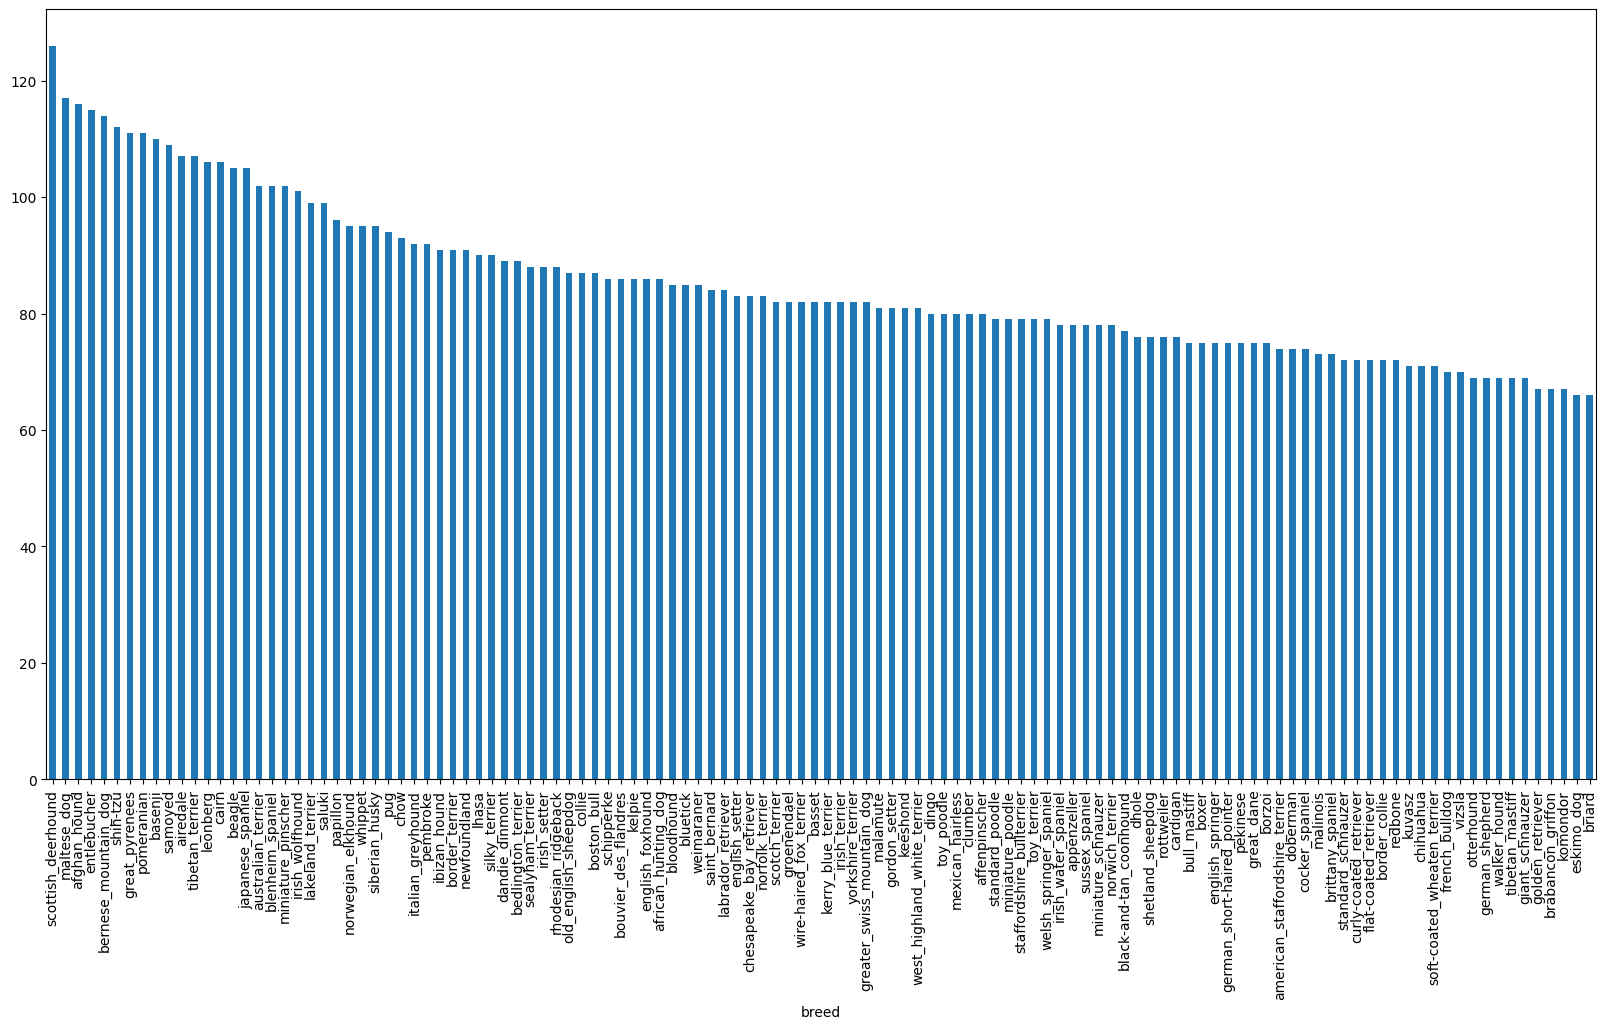

In [ ]:
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10))

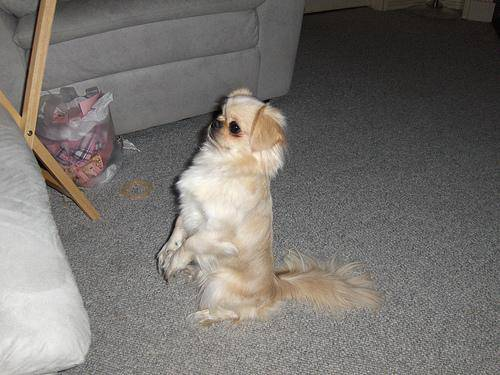

In [ ]:
#lets view an image
from IPython.display import Image
Image("drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/001cdf01b096e06d78e9e5112d419397.jpg")

In [ ]:
#create pathnames form image id's
filenames=["drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/"+fname for fname in labels_csv["id"] +".jpg"]
filenames[:10]

['drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'drive/MyDrive/Colab Notebooks/Dog-b

In [ ]:
#check wether filenames match actuall no. of image files
import os
if len(os.listdir("drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/"))==len(filenames):
  print("filenames match the no. of images")
else:
  print("not matched")

filenames match the no. of images


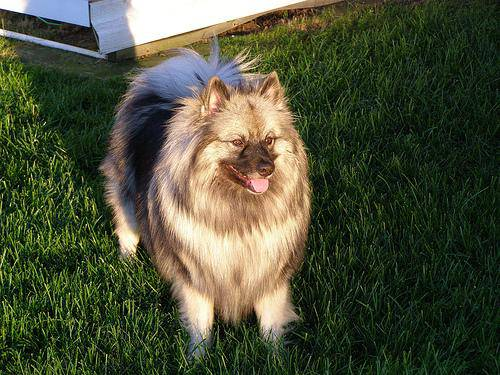

In [ ]:
Image(filenames[4500])

In [ ]:
labels_csv["breed"][4500]

'keeshond'

let's prepare our labels

In [ ]:
import numpy as np
labels=labels_csv["breed"]
labels=np.array(labels)
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [ ]:
#find the unique label value
unique_breeds=np.unique(labels)
len(unique_breeds)

120

In [ ]:
#turinng a label into a boolean array
print(labels[0])
labels[0]==unique_breeds

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [ ]:
#turn every lable into boolean array in place of original label name
boolean_labels= [labels==unique_breeds for labels in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [ ]:
len(boolean_labels)

10222

In [ ]:
#Example : turning boolean array into integers
print(labels[0])#original label
print(np.where(unique_breeds==labels[0]))#index where label occurs
print(boolean_labels[0].argmax())# index where labels occurs in boolean array
print(boolean_labels[0].astype(int)) # there will be a 1 where label occurs

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [ ]:
print(labels[2])
print(boolean_labels[2].astype(int))

pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


# creating our validation set

In [ ]:
#setup x and y variables
x = filenames
y = boolean_labels

In [ ]:
len(filenames)

10222

we are going to start from 1000 images and increase as needed

In [ ]:
#set no of images to use for experimenting
NUM_IMAGES = 8000 # @param {"type":"slider","min":1000,"max":10000,"step":1000}

In [ ]:
#lets split our data into train and validation set
from sklearn.model_selection import train_test_split

#splitting them into train and valid sets of NUM_IMAGES size
x_train, x_valid ,y_train, y_valid=train_test_split(x[:NUM_IMAGES], y[:NUM_IMAGES],
                                                    test_size=0.2,
                                                    random_state=42)
len(x_train),len(x_valid) ,len(y_train),len(y_valid)

(800, 200, 800, 200)

In [ ]:
x_train[:2] ,y_train[:2]

(['drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/00bee065dcec471f26394855c5c2f3de.jpg',
  'drive/MyDrive/Colab Notebooks/Dog-breed-identification/data/train/0d2f9e12a2611d911d91a339074c8154.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False

##Preprocessing images(Turning images into tensors)
To achive the following task we are going to write a function that does :
1. Take an image filepath as an input
2. use Tensorflow to read the file and save it to a variable `image`
3. Turn our `image` (a jpg) into a tensor
4. Normalize our `image`(convert colour channels from 0-255 to 0-1)
4. Resize the `image` to be a size of (244,244)
5. Return the modified image

Before we do so lets see what importing an image looks like

In [ ]:
#convert image to numpy array
import matplotlib.pyplot
from matplotlib.pyplot import imread
image = imread(filenames[20])
image.shape # this give the length and breadth and colour channel of the image(red green and blue =3)

(375, 500, 3)

In [ ]:
image.max(), image.min()

(255, 0)

array([[[127, 128, 120],
        [123, 124, 116],
        [117, 120, 111],
        ...,
        [ 98, 123,  65],
        [ 97, 122,  64],
        [102, 127,  69]],

       [[117, 120, 111],
        [114, 117, 108],
        [112, 115, 106],
        ...,
        [ 97, 123,  62],
        [ 94, 119,  61],
        [ 98, 124,  63]],

       [[113, 118, 111],
        [111, 116, 109],
        [111, 116, 109],
        ...,
        [ 94, 120,  57],
        [ 90, 116,  55],
        [ 92, 118,  55]],

       ...,

       [[228, 227, 225],
        [231, 230, 228],
        [233, 227, 229],
        ...,
        [219, 214, 211],
        [202, 197, 194],
        [190, 185, 182]],

       [[221, 220, 218],
        [234, 233, 231],
        [243, 237, 239],
        ...,
        [222, 217, 214],
        [220, 215, 212],
        [217, 212, 209]],

       [[239, 238, 236],
        [236, 235, 233],
        [227, 221, 223],
        ...,
        [208, 203, 200],
        [216, 211, 208],
        [215, 210, 207]]], dtype=uint8)
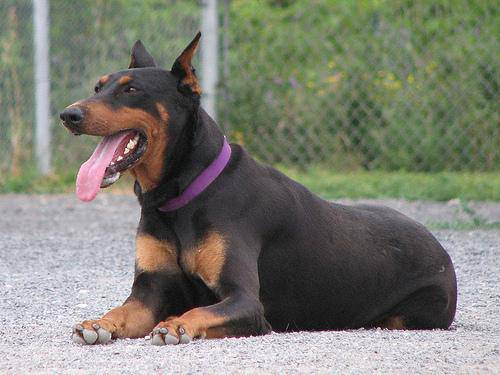

In [ ]:
image

In [ ]:
tf.constant(image) #converts image to tensors

<tf.Tensor: shape=(375, 500, 3), dtype=uint8, numpy=
array([[[127, 128, 120],
        [123, 124, 116],
        [117, 120, 111],
        ...,
        [ 98, 123,  65],
        [ 97, 122,  64],
        [102, 127,  69]],

       [[117, 120, 111],
        [114, 117, 108],
        [112, 115, 106],
        ...,
        [ 97, 123,  62],
        [ 94, 119,  61],
        [ 98, 124,  63]],

       [[113, 118, 111],
        [111, 116, 109],
        [111, 116, 109],
        ...,
        [ 94, 120,  57],
        [ 90, 116,  55],
        [ 92, 118,  55]],

       ...,

       [[228, 227, 225],
        [231, 230, 228],
        [233, 227, 229],
        ...,
        [219, 214, 211],
        [202, 197, 194],
        [190, 185, 182]],

       [[221, 220, 218],
        [234, 233, 231],
        [243, 237, 239],
        ...,
        [222, 217, 214],
        [220, 215, 212],
        [217, 212, 209]],

       [[239, 238, 236],
        [236, 235, 233],
        [227, 221, 223],
        ...,
        [208, 203, 20

In [ ]:
#Define an image size
img_size= 244
#Create a function for preprocessing
def process_image(image_path, IMG_SIZE=img_size):
  ''' Takes an image file and turns it into tensors'''
  #read in an image file
  image=tf.io.read_file(image_path)
  #Turn the jpeg images into numerical tensors with 3 colour channels(red,green,blue)
  image=tf.image.decode_jpeg(image,channels=3) # worls same as tf.constant
  #convert the channel values from 0-255 to 0-1
  image=tf.image.convert_image_dtype(image, tf.float32)
  #Resizing the image
  image=tf.image.resize(image,size=[IMG_SIZE,IMG_SIZE])

  return image




Turning our data into batches

we need our data in the form of tensor tuples (image,label)

In [ ]:
#create a simple function to return tuple image,label
def get_image_label(image_path,label):
  ''' Takes an image filepath and label, converts the image into correspnding
  tensor and returns a tuple of(image,label).'''
  image=process_image(image_path)
  return image, label

lets make a function to turn all of our data x and y into batches

In [ ]:
#define batch size 32 is a good start
BATCH_SIZE=32

#create a function to turn data into batches
